# Neuroadaptive Haptics Data 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# path = 'P:\\Lukas_Gehrke\\NAH\\behavior\\5_single-subject-EEG-analysis'
path = '/Users/lukasgehrke/data/NAH/data/5_single-subject-EEG-analysis/'
fname_dmatrix = 'behavior_all.csv'
fname_participants = 'participants.csv'

design = pd.read_csv(path + fname_dmatrix, delimiter=';')
df_grouped = design.groupby(['id', 'hapticProfile']).mean()

df_participants = pd.read_csv(path + fname_participants)

# participant selection
# discard rows from df_participants where Pilot is Broken
df_participants = df_participants[df_participants['Pilot'] != 'broken']
# only where Pilot is no
# df_participants = df_participants[df_participants['Pilot'] == 'no'] # TODO add in after recordings are done

Trial Ratings vs. Exit Interview Preference: [ ] correlation of condition name with highest mean rating with notion table column 'Preference' - not really that important though, just more of a dummy check, but looking good in pilot data so far

In [2]:
# Find the hapticProfile with the highest answerID for each id
highest_answerID_profiles = df_grouped.groupby('id')['answerID'].idxmax()
# Extract the hapticProfile names
highest_answerID_profiles = highest_answerID_profiles.apply(lambda x: x[1])
# Merge the dataframes based on 'id' in highest_answerID_profiles and 'Dataset' in df_participants
merged_df = pd.merge(highest_answerID_profiles, df_participants, left_on='id', right_on='Dataset')

## Comparing Implicit and Explicit wrong_explicit

### Does the agent converge to the right solution?

To compare how well the “other label” matches the “true label” between two dependent groups, calculate whether each sample is a match (1) or no match (0) in both groups. Create a contingency table showing matches in both groups, mismatches unique to each group, and no matches in either. Use McNemar’s test to assess whether the mismatch proportions differ significantly between the groups, accounting for the dependency. A small p-value (e.g., < 0.05) indicates a significant difference in matching performance between groups. This method is ideal for your scenario, where the groups are not independent, and the labels are categorical.

Contingency Table:
[[0 1]
 [1 4]]
McNemar's test statistic: 1.0
P-value: 1.0
No significant difference between groups (p >= 0.05)


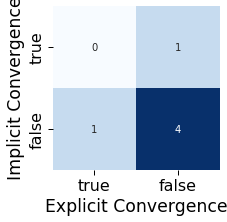

In [3]:
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar

# from merged_df select 'answerID', 'Preference', 'Convergence_Implicit', 'Convergence_Explicit'
df = merged_df[['Dataset', 'Preference', 'answerID', 'Convergence_Implicit', 'Convergence_Explicit']]

# make df as numpy array without column 'Dataset'
data = df.to_numpy()[:, 2:]

# Extract true labels and predictions
highest_rating = data[:, 0]
implicit = data[:, 1]
explicit = data[:, 2]

# Calculate match status for each group (1 = match, 0 = no match)
correct_implicit = (highest_rating == implicit).astype(int)
correct_explicit = (highest_rating == explicit).astype(int)

# Create contingency table for McNemar's test
# Rows: Group 1 match status
# Columns: Group 2 match status
# Contingency table format:
# [[a, b],  # a = matches in both groups, b = match in group1 but not in group2
#  [c, d]]  # c = match in group2 but not in group1, d = no matches in either group

a = np.sum((correct_implicit == 1) & (correct_explicit == 1))  # Matches in both groups
b = np.sum((correct_implicit == 1) & (correct_explicit == 0))  # Match in group1 only
c = np.sum((correct_implicit == 0) & (correct_explicit == 1))  # Match in group2 only
d = np.sum((correct_implicit == 0) & (correct_explicit == 0))  # No matches in either group

contingency_table = np.array([[a, b], [c, d]])

# Perform McNemar's test
result = mcnemar(contingency_table, exact=True)  # Use exact test for small sample sizes

# Output results
print(f"Contingency Table:\n{contingency_table}")
print(f"McNemar's test statistic: {result.statistic}")
print(f"P-value: {result.pvalue}")

if result.pvalue < 0.05:
    print("Significant difference between groups (p < 0.05)")
else:
    print("No significant difference between groups (p >= 0.05)")

with sns.plotting_context('paper', font_scale = 1.8):

    ### Create new plot
    fig, ax = plt.subplots(1, 1, figsize=(3,3))
    fig.patch.set_alpha(1)

    sns.despine() #bottom=True, left=True
    sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['true', 'false'],
                yticklabels=['true', 'false']) #xticklabels=['true_explicit', 'false_explicit'], yticklabels=['true_implicit', 'false_implicit']
    # plt.title("Contingency Table for McNemar's Test")
    plt.xlabel("Explicit Convergence")
    plt.ylabel("Implicit Convergence")
    plt.show()


### Does it converge faster?

In [4]:
import numpy as np
from scipy.stats import ttest_rel, wilcoxon

steps_implicit = merged_df['Steps_Implicit']
steps_explicit = merged_df['Steps_Explicit']

# Compute the differences
differences = steps_explicit - steps_implicit

# Check normality (optional: Shapiro-Wilk test or visual inspection of histogram)
# Here, we'll directly choose tests for simplicity.

# 1. Paired t-test (for normal data)
t_stat, p_ttest = ttest_rel(steps_implicit, steps_explicit)
print(f"Paired t-test: t-statistic = {t_stat:.4f}, p-value = {p_ttest:.4f}")
if p_ttest < 0.05:
    print("Paired t-test: Significant difference between conditions (p < 0.05).")
else:
    print("Paired t-test: No significant difference between conditions (p >= 0.05).")

# 2. Wilcoxon signed-rank test (non-parametric)
w_stat, p_wilcoxon = wilcoxon(steps_implicit, steps_explicit)
print(f"Wilcoxon signed-rank test: W-statistic = {w_stat:.4f}, p-value = {p_wilcoxon:.4f}")
if p_wilcoxon < 0.05:
    print("Wilcoxon test: Significant difference between conditions (p < 0.05).")
else:
    print("Wilcoxon test: No significant difference between conditions (p >= 0.05).")



Paired t-test: t-statistic = -0.2375, p-value = 0.8217
Paired t-test: No significant difference between conditions (p >= 0.05).
Wilcoxon signed-rank test: W-statistic = 8.0000, p-value = 0.6875
Wilcoxon test: No significant difference between conditions (p >= 0.05).


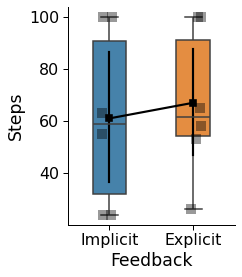

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Melt the dataframe to have a long format suitable for seaborn
df_melted = merged_df.melt(id_vars=['Dataset'], value_vars=['Steps_Implicit', 'Steps_Explicit'], 
                           var_name='Feedback', value_name='Steps')
# rename Steps_Implicit to Implicit and Steps_Explicit to Explicit
df_melted['Feedback'] = df_melted['Feedback'].replace({'Steps_Implicit': 'Implicit', 'Steps_Explicit': 'Explicit'})

# Plotting
with sns.plotting_context('paper', font_scale=1.8):
    fig, ax = plt.subplots(1, 1, figsize=(3, 4))
    fig.patch.set_alpha(1)

    sns.despine()

    # Create the boxplot
    ax = sns.boxplot(data=df_melted, x='Feedback', y='Steps', order=['Implicit', 'Explicit'], hue='Feedback', width=.4, linewidth=1.5)
    for patch in ax.patches:  # adapt alpha
        r, g, b, a = patch.get_facecolor()
        patch.set_facecolor((r, g, b, .9))

    # Add points to show each observation    
    ax = sns.stripplot(data=df_melted, x='Feedback', y='Steps', s=10, legend= True, marker="s", color = 'black',edgecolor = 'black',alpha=0.4)

    # ax = sns.scatterplot(data = df_melted, x ='Feedback', y='Steps', s=50, legend= True, marker="s", color = 'black',edgecolor = 'black',alpha=0.4)

    # Show line connecting means
    ax = sns.pointplot(data=df_melted, x='Feedback', y='Steps', markers="s", color='black', order=['Implicit', 'Explicit'])

    # # Show scatter points
    # ax = sns.scatterplot(data=df_melted, x='Feedback', y='Steps', s=50, legend=False, marker="s", color='black', edgecolor='black', alpha=0.4)

    # Customize the plot
    # ax.set_title("Implicit vs Explicit Steps")
    ax.set_ylabel("Steps")
    ax.set_xlabel("Feedback")

    plt.show()

# Save the figure (optional)
# fig.savefig('results/implicit_vs_explicit_steps.eps', format='eps', transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig('results/implicit_vs_explicit_steps.svg', format='svg', transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig('results/implicit_vs_explicit_steps.png', format='png', transparent=True, bbox_inches='tight', dpi=300)